# Vosk Speaker Recognition Tests

### What is Vosk?

_Vosk_ is an offline speech to text library that can work in python. It is composed of an accoustic neural model followed by a language model. It also provides a voice feature extractor.

### Purpose of this notebook

This notebook aims at finding a good way to discriminate speakers based on their voices. The algorithm should be able to determine when a new, never seen speaker comes into play and distinguish the different speaker.

### Method used

Multiple solutions were considered like a one-shot neural network but the simplest and most reliable solution seems to be the cosine similarity method.

From the extracted voice features vector a cosine similarity value is computed from every known existing speakers' prototype voice feature vector. If one value is smaller than a certain threshold it is considered as spoken by this speaker. If multiple values are below this threshold it is assigned to the speaker with the smallest difference. If no values are below this threshold then a new speaker is created with the prototype being this vector. Finally the speaker prototype vector is updated with this new vector and is the mean of all its known vectors (TODO maybe not all the vectors, to determine later, not during the "training").

The last thing needed is the value of that threshold. It should be determined empirically, learned from some training data. This notebook will analyse the intra-speaker and extra-speaker cosine similarity value from a small dataset and test multiple threshold extracted from a statistical analysis of those values to determine the best disciminative threshold.

## Libraries
- `Vosk` : a speach to text library. `Model` is for speech to text, `SpkModel` is for the speaker models, `KaldiRecognizer` is basically the language model that makes coherent sentences from words
- `json` : to save data in a sturctured manner
- `subprocess` : to create a subprocess that turns `.flac` compressed audio files into `.wav` to feed vosk model

In [1]:
from vosk import Model, SpkModel, KaldiRecognizer
import json
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_curve, auc

In [2]:
from vosk import SetLogLevel
SetLogLevel(-1)

## Models
- `model` : vosk transcriber model
- `spk_model` : vosk speaker voice embedder

In [3]:
model = Model("/opt/models/vosk-model-en-us-0.22")
spk_model = SpkModel("/opt/models/vosk-model-spk-0.4")

WARNING (VoskAPI:Check():nnet-nnet.cc:789) Node tdnn6.relu is never used to compute any output.
WARNING (VoskAPI:Check():nnet-nnet.cc:789) Node tdnn6.batchnorm is never used to compute any output.
WARNING (VoskAPI:Check():nnet-nnet.cc:789) Node output.affine is never used to compute any output.
WARNING (VoskAPI:Check():nnet-nnet.cc:789) Node output.log-softmax is never used to compute any output.


## Dataset

Get the speakers' id, and the chapters's id they read into a dataframe

In [4]:
DS_DIR = "/opt/dataset/LibriSpeech/"
SPEAKERS_TXT = DS_DIR + "SPEAKERS.TXT"
CHAPTERS_TXT = DS_DIR + "CHAPTERS.TXT"
CURRENT_DS = "dev-clean"


# use a dict with reader id as the key
# to find them faster when adding the chapters they read
speakers = {}

# get the speakers that are in this dataset
with open(SPEAKERS_TXT) as speakers_file:
    for speaker in speakers_file:
        if speaker[0] == ';' :
            continue
        # split the data
        speaker_properties = speaker.split(" | ")
        # verify if it is the correct dataset
        speaker_ds = speaker_properties[2].split(" ")[0]
        if speaker_ds != CURRENT_DS :
            continue
        # get the speaker id
        speaker_id = int(speaker_properties[0])
        speakers[speaker_id] = { "chapters": [] }

# add the chapters
with open(CHAPTERS_TXT) as chapters:
    for chapter in chapters:
        if chapter[0] == ';' :
            continue
        # split the data
        chapter_properties = chapter.split(" | ")
        # verify if it is a correct speaker
        speaker_id = int(chapter_properties[1])
        if speaker_id not in speakers :
            continue
        # get the chapter id
        chapter_id = int(chapter_properties[0])
        # add it to the chapters that this speaker read
        speakers[int(speaker_id)]["chapters"] += [chapter_id]

print(f"{CURRENT_DS} have {len(speakers)} speakers")

# turns it into a df
speakers_df = [ { "id" : speaker_id, "chapters" : chapters["chapters"] }
             for speaker_id, chapters in speakers.items() ]
speakers_df = pd.DataFrame(speakers_df)

# showcase
print(speakers_df[0:5])

dev-clean have 40 speakers
    id                  chapters
0   84          [121123, 121550]
1  174    [50561, 84280, 168635]
2  251  [118436, 136532, 137823]
3  422                  [122949]
4  652  [129742, 130726, 130737]


## Data Loaders
Those functions yields every samples for a chapter and for every chapter of a reader.

In [5]:
def samples_in_chapter(reader_id, chapter_id):
    # get the path of the transcript
    chapter_dir = f"{DS_DIR}{CURRENT_DS}/{reader_id}/{chapter_id}"
    trans_filename = f"{reader_id}-{chapter_id}.trans.txt"
    trans_path = f"{chapter_dir}/{trans_filename}"
    # get all the samples' filenames and transcripts
    with open(trans_path) as chapters_trans:
        for sample in chapters_trans:
            sample = sample.split(" ", 1)
            trans = sample[1].lower()
            sample_filename = sample[0]
            sample_path = f"{chapter_dir}/{sample_filename}.flac"
            yield(reader_id, chapter_id, sample_path, trans)

In [6]:
def samples_of_speaker(reader_id):
    # get all the samples's info of the reader's chapters
    for chapter_id in speakers[reader_id]['chapters']:
        yield from samples_in_chapter(reader_id, chapter_id)

## Voice Embedder

This function uses the vosk speaker model to obtain the embeddings that will be used to find the empirically perfect threshold. Vosk segments the input text. The embeddings of those different segments are accumulated.

In [7]:
rec = KaldiRecognizer(model, 16000)
rec.SetSpkModel(spk_model)

In [8]:
def embed_speaker(filename):
    # to turn the original file into wav
    process = subprocess.Popen(
        [
            "ffmpeg",
            "-loglevel", "quiet",
            "-i", filename,
            "-ar", "16000",
            "-ac", "1",
            "-f", "s16le",
            "-"
        ],
        stdout=subprocess.PIPE
    )

    embeddings = []
    while True:
        data = process.stdout.read(4000)
        if len(data) == 0:
            break
        if rec.AcceptWaveform(data):
            result = json.loads(rec.Result())
            try:
                embeddings += [result["spk"]]
            except KeyError:
                pass

    result = json.loads(rec.Result())
    try:
        embeddings += [result["spk"]]
    except KeyError:
        pass
        
    return embeddings

In [9]:
# test the embedder

first_speaker_id = int(speakers_df["id"][0])
samples = samples_of_speaker(first_speaker_id)
first_sample = next(samples)
print(first_sample)
sample_file = first_sample[2]
embeddings = embed_speaker(sample_file)
print(embeddings)


(84, 121123, '/opt/dataset/LibriSpeech/dev-clean/84/121123/84-121123-0000.flac', 'go do you hear\n')
[[0.676524, -0.174708, 1.391595, -0.160335, -0.838526, 0.184473, 2.021083, -0.015563, -0.179584, -0.292866, 1.258216, 0.345898, -1.261073, 0.441368, -1.414813, 1.117888, -0.937886, -0.631057, -0.599601, -0.876271, 0.72706, 0.042779, -0.499257, -0.954933, 0.500851, -0.752639, -0.73744, 0.653585, 1.18631, -1.047964, -1.100774, 1.358306, 0.252064, 0.750946, 0.13596, -0.56771, 0.939724, 0.718971, -0.935821, -1.454744, 0.154151, 0.929311, 1.859549, -0.231316, -1.761168, -0.188521, 1.571713, -1.7409, -1.54364, -0.287507, 0.48669, 0.815884, 0.456254, -0.211038, -0.142606, -0.945827, 1.880592, -0.488176, -0.074415, -0.552172, 1.621447, 0.459643, -0.211306, 1.163238, 1.227555, -0.392374, 1.837263, 0.023443, 0.027641, 1.092584, 0.421459, -0.772115, 1.779357, 1.023121, 0.123081, -0.818832, 0.175796, -0.555644, -1.075902, -2.61072, 2.035837, 0.233901, -0.74449, -0.647214, -0.78381, -0.118931, 1.083

In [10]:
def get_speaker_embeddings(speaker_id):
    samples = samples_of_speaker(speaker_id)
    embeddings = []
    for sample in samples :
        sample_file = sample[2]
        embeddings += embed_speaker(sample_file)
    return np.array(embeddings)

In [11]:
speakers_embeddings = []
embedding_filename = f"speakers_embeddings_{CURRENT_DS}.npz"

try:
    data = np.load(embedding_filename)
    speakers_embeddings = [data[f'arr_{i}'] for i in range(len(data.files))]
    print(f"Loaded {embedding_filename}")
except FileNotFoundError:
    for _, speaker in tqdm(speakers_df.iterrows(), total=len(speakers_df),
                           desc="embedding speakers",unit="speaker"):
        speakers_embeddings += [get_speaker_embeddings(speaker["id"])]
    np.savez(embedding_filename, *speakers_embeddings)

Loaded speakers_embeddings_dev-clean.npz


## Data Preparation

Remove speakers who speak not enough and the ones who speak too much to keep a good balance. Outliers are defined the data greater than the 3rd quartile + 1.5 inter-quantile range or smaller than the 1st quartile - 1.5 iqr.

embeddings are then normalized.

In [12]:
nb_samples = np.array([emb.shape[0] for emb in speakers_embeddings])
q1, q3 = np.percentile(nb_samples, [25, 75])
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

filtered_speakers_embeddings = [
    emb for emb in speakers_embeddings
    if lower <= emb.shape[0] <= upper
]

print(f"removed {len(speakers_embeddings) -
                     len(filtered_speakers_embeddings)} speakers")

removed 0 speakers


In [13]:
def normalize(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)

filtered_speakers_embeddings = [normalize(emb) for emb
                                in filtered_speakers_embeddings]

## Intra and Inter-Similarities

The intra and inter cosine similarities are computed pair-wise and not on centroid because when running in the application it will be a new single sample that will be computed.

In [14]:
intra_similarities = []
inter_similarities = []

for i, emb in enumerate(filtered_speakers_embeddings):
    sim_matrix = cosine_similarity(emb)

    #intra-similarities
    # take upper triangle without diagonal
    n = sim_matrix.shape[0]
    intra = sim_matrix[np.triu_indices(n, k=1)]
    intra_similarities.extend(intra)

    #inter-similarities
    for j in range(i + 1, len(filtered_speakers_embeddings)):
        emb_j = filtered_speakers_embeddings[j]
        # Compute all pairwise similarities between speaker i and j
        cross_sim = cosine_similarity(emb, emb_j)
        inter_similarities.extend(cross_sim.ravel())

intra_similarities = np.array(intra_similarities)
inter_similarities = np.array(inter_similarities)
intra_mean = np.mean(intra_similarities)
intra_std  = np.std(intra_similarities)
print(f"Mean intra-speaker similarity: {intra_mean:.4f}  (std = {intra_std:.4f}, n_pairs = {len(intra_similarities)})")
inter_mean = np.mean(inter_similarities)
inter_std  = np.std(inter_similarities)
print(f"Mean inter-speaker similarity: {inter_mean:.4f}  (std = {inter_std:.4f}, n_pairs = {len(inter_similarities)})")

Mean intra-speaker similarity: 0.6106  (std = 0.1240, n_pairs = 99943)
Mean inter-speaker similarity: 0.2293  (std = 0.1435, n_pairs = 3762867)


## Best Threshold

After looking at many theoretical values to decide for the best threshold the EER (Equal Error Rate) was chosen as it balances errors on same speaker and on different speakers.

The problem with minimizing total error rate is that 

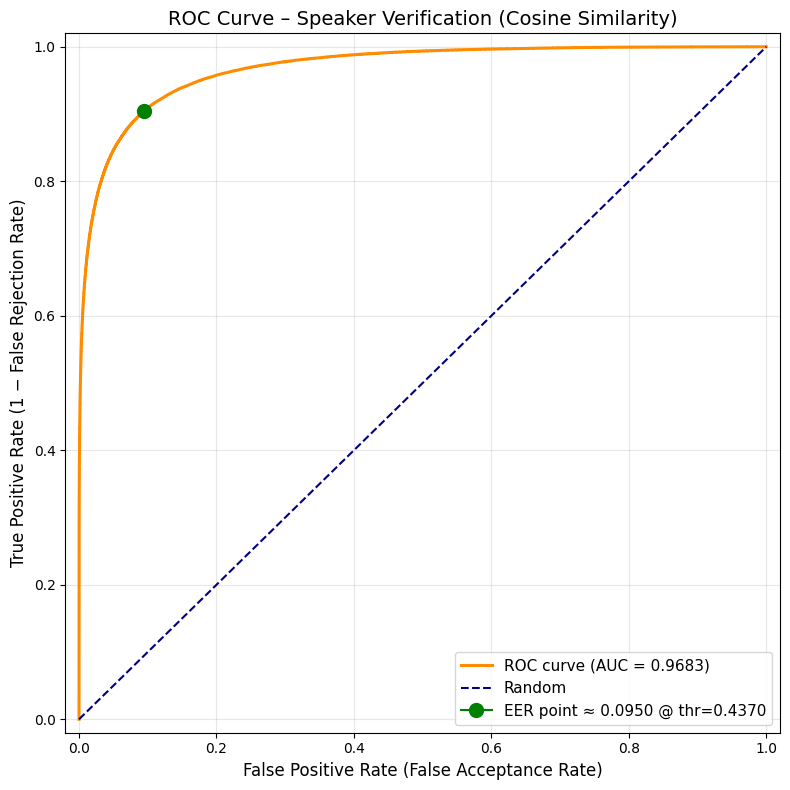

Equal Error Rate (EER)     : 0.0950  (9.50%)
Optimal threshold (EER)    : 0.4370


In [15]:
scores = np.concatenate([intra_similarities, inter_similarities])
labels = np.concatenate([
    np.ones(len(intra_similarities)),
    np.zeros(len(inter_similarities))
])

fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1,
                                 drop_intermediate=False)
roc_auc = auc(fpr, tpr)

eer_idx = np.nanargmin(np.abs(fpr - (1 - tpr)))
eer = (fpr[eer_idx] + (1 - tpr[eer_idx])) / 2
eer_threshold = thresholds[eer_idx]

# plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2.2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random')

plt.plot(fpr[eer_idx], tpr[eer_idx], marker='o', markersize=10,
         color='green', label=f'EER point ≈ {eer:.4f} @ thr={eer_threshold:.4f}')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (False Acceptance Rate)', fontsize=12)
plt.ylabel('True Positive Rate (1 − False Rejection Rate)', fontsize=12)
plt.title('ROC Curve – Speaker Verification (Cosine Similarity)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

print(f"Equal Error Rate (EER)     : {eer:.4f}  ({eer*100:.2f}%)")
print(f"Optimal threshold (EER)    : {eer_threshold:.4f}")

## Similarity Distribution

Here are the distributions of inter and intra speaker similarity with their mean and median score plus the chosen threshold.

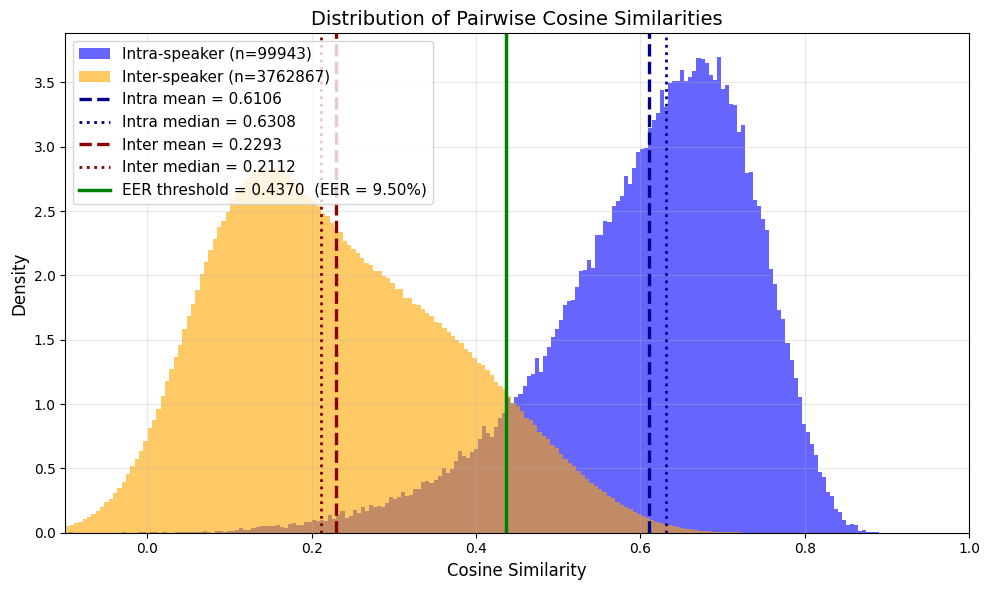

In [16]:
plt.figure(figsize=(10, 6))

# Histograms
plt.hist(intra_similarities, bins=200, alpha=0.6, density=True,
         label=f'Intra-speaker (n={len(intra_similarities)})', color='blue')
plt.hist(inter_similarities, bins=200, alpha=0.6, density=True, 
         label=f'Inter-speaker (n={len(inter_similarities)})', color='orange')

# Vertical lines for mean and median
plt.axvline(x=np.mean(intra_similarities), color='darkblue', linestyle='--', linewidth=2.4,
            label=f'Intra mean = {np.mean(intra_similarities):.4f}')
plt.axvline(x=np.median(intra_similarities), color='navy', linestyle=':', linewidth=2.0,
            label=f'Intra median = {np.median(intra_similarities):.4f}')

plt.axvline(x=np.mean(inter_similarities), color='darkred', linestyle='--', linewidth=2.4,
            label=f'Inter mean = {np.mean(inter_similarities):.4f}')
plt.axvline(x=np.median(inter_similarities), color='maroon', linestyle=':', linewidth=2.0,
            label=f'Inter median = {np.median(inter_similarities):.4f}')

plt.axvline(eer_threshold, color='green', linestyle='-', linewidth=2.5,
            label=f'EER threshold = {eer_threshold:.4f}  (EER = {eer*100:.2f}%)')

plt.title('Distribution of Pairwise Cosine Similarities', fontsize=14)
plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(-0.1, 1.0)
plt.tight_layout()

plt.savefig("speaker_similarity_distributions.png")
plt.show()